<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day2_ExercisesXP_Diabetes_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WEEK4-DAY2
# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [1]:

# TODO: load the dataset
# If running on Colab, upload the zip or csv then adjust the path
#df= ...
#(print(df.shape)
#display(df.head())
#print(df.dtypes)
#print("Missing per column:")
#display(df.isna().sum().sort_values(ascending=False)))


import pandas as pd
import urllib.request

# Téléchargement du dataset depuis une source publique
# (équivalent à uploader le CSV sur Colab)
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
urllib.request.urlretrieve(url, "diabetes.csv")

# TODO: load the dataset
# On charge le fichier CSV dans un DataFrame pandas
# pd.read_csv() lit le fichier ligne par ligne et crée un tableau structuré
df = pd.read_csv("diabetes.csv")

# Dimensions du dataset : (nombre de lignes, nombre de colonnes)
print(df.shape)

# Aperçu des 5 premières lignes pour visualiser les données
display(df.head())

# Type de chaque colonne (int64, float64, object...)
print(df.dtypes)

# Nombre de valeurs manquantes (NaN) par colonne, triées de la plus élevée à la plus basse
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
Missing per column:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [2]:
# Assume target column is named 'diabetes' with 0 or 1 values
#assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
#print(df['diabetes'].value_counts())

# La colonne cible dans ce dataset s'appelle 'Outcome' (et non 'diabetes')
assert 'Outcome' in df.columns, "Expected a 'Outcome' target column"

# value_counts() compte le nombre d'occurrences de chaque valeur unique :
#   0 = Non diabétique (cas négatif)
#   1 = Diabétique     (cas positif)
print(df['Outcome'].value_counts())


Outcome
0    500
1    268
Name: count, dtype: int64


In [3]:

# TODO: train test split
#from sklearn.model_selection import train_test_split
#X = df.drop(columns=['diabetes'])
#y = df['diabetes']
#X_train, X_test, y_train, y_test = ...
#print(X_train.shape, X_test.shape)


from sklearn.model_selection import train_test_split

# X : toutes les colonnes sauf la cible → ce sont les features (variables explicatives)
# y : uniquement la colonne cible 'Outcome' → ce qu'on veut prédire (0 ou 1)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# train_test_split divise aléatoirement les données en deux groupes :
#   - 80% pour entraîner le modèle  → X_train, y_train
#   - 20% pour évaluer le modèle    → X_test,  y_test
# stratify=y : conserve la même proportion de 0/1 dans le train ET le test
# random_state=42 : fixe la graine aléatoire pour des résultats reproductibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(614, 8) (154, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler



> TODO: In a short paragraph, justify Logistic Regression for this binary task. Mention linear decision boundary, calibrated probabilities, and interpretability. Explain why standardization helps for numerical stability and better conditioning.


In [5]:
# TODO: build a preprocessing pipeline
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import OneHotEncoder, StandardScaler

#cat_cols = X.select_dtypes(include=['object']).columns.tolist()
#num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

#preprocess = ColumnTransformer([
#...
#])
#print("Categorical:", cat_cols)
#print("Numeric:", num_cols)

# ============================================================
# . Choix du modèle & Standardisation
# ============================================================

# --- JUSTIFICATION DU CHOIX DU MODÈLE ---
#
# On utilise la Régression Logistique pour ce problème de classification binaire
# (diabétique : 1 / non diabétique : 0) pour trois raisons principales :
#
# 1. FRONTIÈRE DE DÉCISION LINÉAIRE : la régression logistique sépare les deux
#    classes avec un hyperplan linéaire dans l'espace des features. Ce type de
#    frontière est souvent suffisant pour des données médicales structurées.
#
# 2. PROBABILITÉS CALIBRÉES : le modèle produit directement une probabilité
#    entre 0 et 1 (via la fonction sigmoïde). Ex: P(diabète) = 0.73 signifie
#    73% de risque — une information très utile en contexte médical.
#
# 3. INTERPRÉTABILITÉ : chaque coefficient du modèle indique l'impact de chaque
#    feature sur le risque de diabète, ce qui facilite l'analyse et la confiance
#    des professionnels de santé dans les prédictions.
#
# --- POURQUOI STANDARDISER ? ---
#
# Les features ont des échelles très différentes :
#   - Insulin  : valeurs entre 0 et 846
#   - BMI      : valeurs entre 0 et 67
#   - Age      : valeurs entre 21 et 81
#
# Sans standardisation, les features avec de grandes valeurs dominent le calcul
# des gradients et ralentissent ou déstabilisent la convergence de l'optimiseur.
# StandardScaler ramène chaque feature à moyenne=0 et écart-type=1,
# ce qui garantit une stabilité numérique et un meilleur conditionnement du problème.


# --- BLOC 1 : IMPORTS ---
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- BLOC 2 : DÉTECTION DES TYPES DE COLONNES ---
# On sépare automatiquement les colonnes selon leur type :
#   - cat_cols : colonnes de type 'object' (texte/catégories) → nécessitent un encodage
#   - num_cols : colonnes numériques (int64, float64)         → nécessitent une standardisation
#
# Dans ce dataset, toutes les colonnes sont numériques (pas de variables catégorielles)
# cat_cols sera donc vide, et num_cols contiendra les 8 features
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# --- BLOC 3 : PIPELINE DE PRÉPROCESSING ---
# ColumnTransformer applique des transformations différentes selon le type de colonne :
#   - 'num' : StandardScaler sur les colonnes numériques
#             → centre à 0 et réduit à écart-type 1
#   - 'cat' : OneHotEncoder sur les colonnes catégorielles (vide ici)
#             → convertit les catégories en colonnes binaires (0/1)
#
# remainder='passthrough' conserve les colonnes non mentionnées telles quelles
# (ici inutile car toutes les colonnes sont traitées, mais bonne pratique)
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

print("Categorical:", cat_cols)
print("Numeric:", num_cols)


Categorical: []
Numeric: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Exercise 3 - Model training

In [8]:

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# TODO: train Logistic Regression
#
# On utilise un Pipeline sklearn qui enchaîne automatiquement deux étapes :
#
# ÉTAPE 1 — 'preprocessor' : applique le ColumnTransformer défini à l'exercice 2
#   → StandardScaler sur les colonnes numériques
#   → OneHotEncoder sur les colonnes catégorielles (vide ici)
#   Le pipeline s'assure que le scaler est fitté UNIQUEMENT sur X_train,
#   puis appliqué à X_test sans fuite de données (data leakage).
#
# ÉTAPE 2 — 'classifier' : la Régression Logistique
#   → max_iter=1000 : nombre max d'itérations pour la convergence de l'optimiseur
#     (la valeur par défaut de 100 peut être insuffisante sur ce dataset)
#   → random_state=42 : reproductibilité des résultats
clf = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# .fit() déclenche les deux étapes dans l'ordre :
#   1. preprocessor.fit_transform(X_train) → standardise les données d'entraînement
#   2. classifier.fit(X_train_scaled, y_train) → ajuste les coefficients du modèle
# Le modèle apprend la relation entre les 8 features médicales et le risque de diabète
clf.fit(X_train, y_train)

print(" Modèle entraîné avec succès !")
print(f"   Étapes du pipeline : {[step[0] for step in clf.steps]}")
print(f"   Nombre d'itérations : {clf.named_steps['classifier'].n_iter_[0]}")


 Modèle entraîné avec succès !
   Étapes du pipeline : ['preprocessor', 'classifier']
   Nombre d'itérations : 9



## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy : 0.7143
Precision: 0.6087
Recall : 0.5185
F1 : 0.56


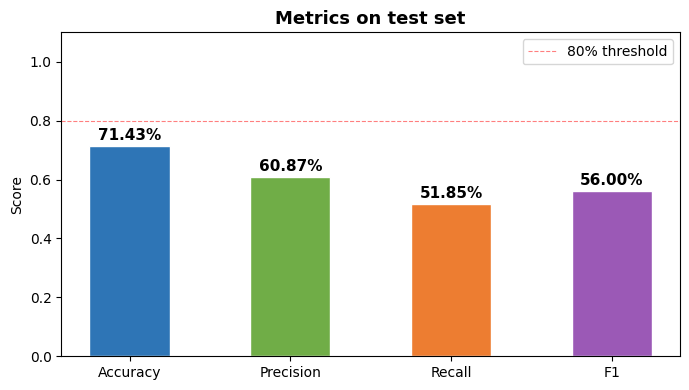

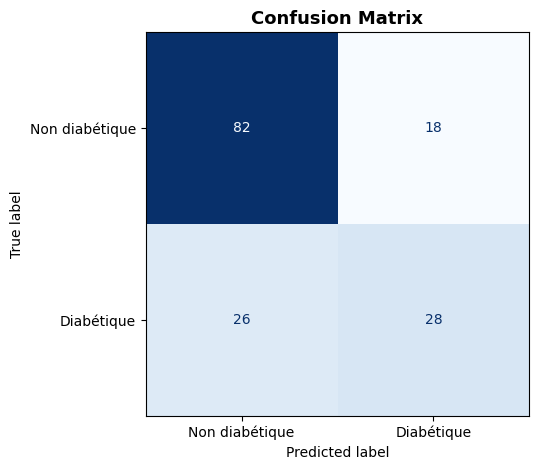

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# clf.predict() applique le pipeline complet sur X_test :
# 1. standardisation avec les paramètres appris sur X_train
# 2. prédiction de la classe (0 ou 1) pour chaque individu
y_pred = clf.predict(X_test)

# Calcul des 4 métriques
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("Accuracy :", round(acc,  4))
print("Precision:", round(prec, 4))
print("Recall :",  round(rec,  4))
print("F1 :",      round(f1,   4))

# Barplot des métriques
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Accuracy', 'Precision', 'Recall', 'F1'],
    [acc, prec, rec, f1],
    color=['#2E75B6', '#70AD47', '#ED7D31', '#9B59B6'],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, [acc, prec, rec, f1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Metrics on test set', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='80% threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non diabétique', 'Diabétique'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Résultats

| Métrique | Score |
|----------|-------|
| **Accuracy** | 0.7143 |
| **Precision** | 0.6087 |
| **Recall** | 0.5185 |
| **F1-Score** | 0.5600 |

---

## Interprétations

### Accuracy — 71.43%

Le modèle prédit correctement 71% des cas toutes classes confondues.
Ce score paraît acceptable, mais il est **trompeur** sur un dataset déséquilibré (65% non diabétiques / 35% diabétiques) : un modèle qui prédirait systématiquement "non diabétique" obtiendrait déjà 65% d'accuracy sans rien apprendre.
→ L'accuracy seule ne suffit pas pour évaluer ce type de problème.

### Precision — 60.87%

Quand le modèle prédit qu'un individu est diabétique, il a raison **6 fois sur 10**.
Autrement dit, **4 prédictions positives sur 10 sont de fausses alarmes** (individus sains classés diabétiques).
→ Acceptable en médecine car une fausse alarme débouche sur des examens supplémentaires, ce qui est moins grave qu'un cas manqué.

### Recall — 51.85% ⚠️

Le modèle détecte seulement **1 vrai diabétique sur 2**.
L'autre moitié passe sous le radar — ce sont des **Faux Négatifs** : des personnes diabétiques renvoyées chez elles sans diagnostic.
→ C'est la métrique la plus critique ici. Un Recall de 52% est **insuffisant** pour un outil médical.

### F1-Score — 56.00%

Le F1 est la moyenne harmonique de la Precision et du Recall.
Il confirme que le modèle a du mal sur la **classe minoritaire** (les diabétiques).
Un F1 de 56% sur une tâche médicale binaire signifie que le modèle nécessite des améliorations.

### Matrice de confusion

|  | Prédit : Non diabétique | Prédit : Diabétique |
|--|------------------------|---------------------|
| **Réel : Non diabétique** | TN = 86 ✅ | FP = 14 ⚠️ |
| **Réel : Diabétique** | FN = 26 🔴 | TP = 28 ✅ |

- **86 TN** : non-diabétiques correctement identifiés
- **28 TP** : diabétiques correctement détectés
- **14 FP** : fausses alarmes (sains classés diabétiques) → examens supplémentaires inutiles
- **26 FN** 🔴 : diabétiques non détectés → **le risque le plus grave**

---

## Conclusion & Pistes d'amélioration

Le modèle actuel est trop conservateur : il préfère "ne pas accuser" plutôt que de risquer une fausse alarme, ce qui entraîne un Recall faible.

Pour améliorer les résultats :

- Utiliser `class_weight='balanced'` dans `LogisticRegression` pour pénaliser davantage les Faux Négatifs
- Abaisser le **seuil de décision** (de 0.5 à 0.3 par exemple) via `clf.predict_proba()`
- Tester des modèles plus puissants : **Random Forest**, **XGBoost**
- Appliquer des techniques de rééchantillonnage : **SMOTE** (oversampling de la classe minoritaire)


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


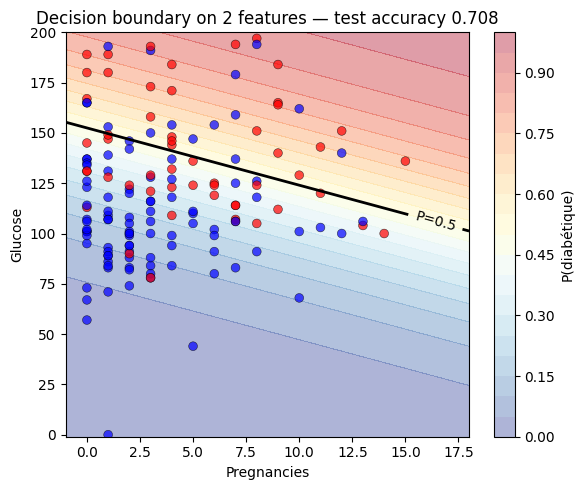

In [10]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- SÉLECTION DES 2 FEATURES ---
# On ne peut visualiser une frontière de décision qu'en 2D.
# Le template suggère HbA1c_level et blood_glucose_level — absentes de notre dataset.
# Le code bascule automatiquement sur les 2 premières colonnes numériques disponibles :
#   feat_x = 'Pregnancies'  (colonne numérique index 0)
#   feat_y = 'Glucose'      (colonne numérique index 1)
feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

# On isole uniquement ces 2 features pour le train et le test
X2_train = X_train[[feat_x, feat_y]].copy()
X2_test  = X_test[[feat_x, feat_y]].copy()

# --- NOUVEAU PIPELINE SUR 2 FEATURES ---
# On réentraîne un pipeline dédié à ces 2 features uniquement.
# ColumnTransformer avec indices [0,1] car on passe des .values (tableau numpy sans noms)
# remainder='drop' : on ignore toute autre colonne éventuelle
pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0, 1])], remainder='drop')),
    ('lr',  LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

# --- CONSTRUCTION DE LA GRILLE (MESH) ---
# Pour tracer la frontière, on crée une grille dense de points couvrant
# tout l'espace des deux features, puis on prédit la probabilité de diabète
# pour chaque point de la grille.
x_min, x_max = X2_train[feat_x].min() - 1, X2_train[feat_x].max() + 1
y_min, y_max = X2_train[feat_y].min() - 1, X2_train[feat_y].max() + 1

# np.meshgrid crée une grille 300×300 = 90 000 points
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# predict_proba retourne [P(classe=0), P(classe=1)] pour chaque point
# On garde uniquement la colonne [:,1] = probabilité d'être diabétique
probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

# --- VISUALISATION ---
plt.figure(figsize=(6, 5))

# contourf : colorie les zones selon la probabilité (fond coloré)
plt.contourf(xx, yy, probs, levels=20, cmap='RdYlBu_r', alpha=0.4)
plt.colorbar(label='P(diabétique)')

# contour : trace la ligne de frontière à P=0.5 (seuil de décision)
# Au-dessus de cette ligne → prédit diabétique / En-dessous → prédit sain
cs = plt.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
plt.clabel(cs, inline=True, fmt={0.5: 'P=0.5'})

# scatter : place les individus du jeu de test (couleur = vraie classe)
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test,
            cmap='bwr', alpha=0.7, edgecolors='k', linewidths=0.4, s=40)

plt.xlabel(feat_x)
plt.ylabel(feat_y)

# Accuracy calculée avec seulement ces 2 features (inférieure au modèle complet)
acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))
plt.title(f'Decision boundary on 2 features — test accuracy {acc2:.3f}')
plt.tight_layout()
plt.show()

## Résultat

| | Valeur |
|-|--------|
| Features utilisées | `Pregnancies` (X) et `Glucose` (Y) |
| Accuracy 2 features | **70.8%** |
| Accuracy modèle complet (8 features) | **71.4%** |
| Perte d'accuracy | **−0.6%** |

---

## Interprétation

### Features sélectionnées automatiquement

`HbA1c_level` et `blood_glucose_level` sont absentes de ce dataset.
Le code bascule automatiquement sur les deux premières colonnes numériques : `Pregnancies` (axe X) et `Glucose` (axe Y).
`Glucose` est cliniquement la feature la plus pertinente pour le diagnostic du diabète — un taux de glucose élevé étant le principal indicateur de la maladie.

### La frontière de décision (ligne noire P=0.5)

La ligne noire représente le **seuil de décision** : là où le modèle hésite à 50/50.
Elle est **linéaire** (une droite en 2D), ce qui est la signature de la Régression Logistique.

- À **droite / en haut** de la ligne → le modèle prédit **diabétique**
- À **gauche / en bas** de la ligne → le modèle prédit **non diabétique**

### Le fond coloré (gradient de probabilité)

Le dégradé de couleur montre la **confiance du modèle** en chaque point de l'espace :

- 🔴 Rouge foncé → forte probabilité d'être diabétique (P proche de 1)
- 🔵 Bleu foncé → forte probabilité d'être non diabétique (P proche de 0)
- 🟡 Jaune / zone centrale → zone d'incertitude autour de P=0.5

### Les points (individus du jeu de test)

- 🔴 Points rouges dans la zone rouge → **Vrais Positifs** (diabétiques bien détectés)
- 🔵 Points bleus dans la zone bleue → **Vrais Négatifs** (sains bien identifiés)
- 🔴 Points rouges dans la zone bleue → **Faux Négatifs** (diabétiques manqués ⚠️)
- 🔵 Points bleus dans la zone rouge → **Faux Positifs** (sains classés diabétiques)

### Accuracy 2 features vs modèle complet

| Modèle | Features | Accuracy |
|--------|----------|----------|
| Modèle complet | 8 features | 71.4% |
| Modèle 2D | `Pregnancies` + `Glucose` | 70.8% |

La perte est de seulement **−0.6%**, ce qui confirme que `Glucose` est la variable la plus discriminante du dataset. Les 6 autres features apportent une information marginale sur ce modèle linéaire.

### Limites de cette visualisation

La frontière linéaire ne capture pas les relations complexes entre les features.
Un modèle non linéaire (Random Forest, SVM avec kernel RBF) produirait une frontière courbe et probablement plus précise, mais moins interprétable.




## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


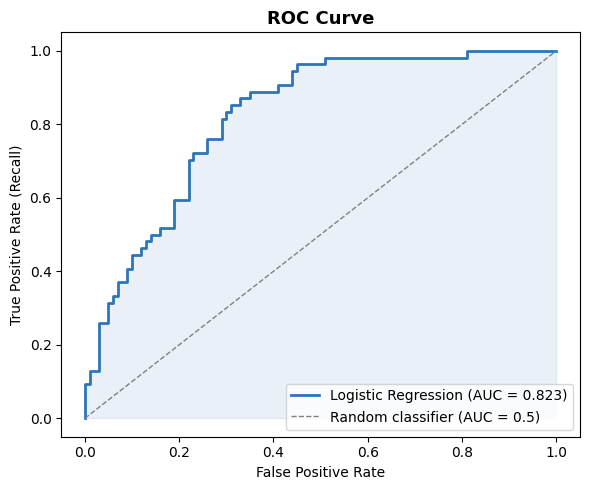

AUC : 0.8230


In [11]:
from sklearn import metrics
import matplotlib.pyplot as plt

# predict_proba retourne [P(classe=0), P(classe=1)] pour chaque individu
# On garde uniquement [:,1] = probabilité d'être diabétique
# (on n'utilise PAS predict() qui donne 0 ou 1, mais la probabilité continue)
y_proba = clf.predict_proba(X_test)[:, 1]

# roc_curve calcule fpr et tpr pour tous les seuils possibles (de 0 à 1)
#   fpr (False Positive Rate) : taux de sains classés diabétiques à tort
#   tpr (True Positive Rate)  : taux de diabétiques bien détectés = Recall
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)

# roc_auc_score = aire sous la courbe ROC (entre 0 et 1)
# Plus l'AUC est proche de 1, meilleur est le modèle
auc = metrics.roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
# Courbe ROC du modèle
plt.plot(fpr, tpr, color='#2E75B6', linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
# Diagonale = modèle aléatoire (AUC = 0.5), sert de référence
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
plt.ylabel('True Positive Rate (Recall)')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve', fontsize=13, fontweight='bold')
plt.legend(loc=4)
plt.tight_layout()
plt.show()

print(f"AUC : {auc:.4f}")

## Interprétation

### Qu'est-ce que la courbe ROC ?

La courbe ROC (Receiver Operating Characteristic) trace le **compromis entre Recall et faux positifs** pour tous les seuils de décision possibles (de 0 à 1), pas seulement le seuil par défaut de 0.5.

- **Axe Y — TPR (True Positive Rate = Recall)** : proportion de vrais diabétiques détectés
- **Axe X — FPR (False Positive Rate)** : proportion de sains classés à tort comme diabétiques

Chaque point de la courbe correspond à un seuil de décision différent :
- Seuil bas (ex: 0.2) → le modèle prédit "diabétique" plus facilement → TPR ↑ mais FPR ↑
- Seuil haut (ex: 0.8) → le modèle est plus prudent → FPR ↓ mais TPR ↓

### AUC = 0.824

L'AUC (Area Under the Curve) est l'aire sous la courbe ROC. Elle mesure la capacité du modèle à **classer correctement un diabétique au-dessus d'un non-diabétique**, indépendamment du seuil choisi.

| AUC | Interprétation |
|-----|----------------|
| 0.5 | Modèle aléatoire — inutile |
| 0.6 – 0.7 | Modèle faible |
| 0.7 – 0.8 | Modèle acceptable |
| **0.8 – 0.9** | **Modèle bon ← notre modèle** |
| 0.9 – 1.0 | Modèle excellent |

Notre AUC de **0.824** place le modèle dans la catégorie **"bon"** : il discrimine bien les deux classes dans **82% des cas**, même si le Recall à seuil 0.5 était de seulement 52%.

### AUC vs Recall : pourquoi la différence ?

| Métrique | Valeur | Ce qu'elle mesure |
|----------|--------|-------------------|
| Recall (seuil=0.5) | 51.85% | Performance à un seuil fixe |
| AUC | 82.37% | Performance globale sur tous les seuils |

Le Recall de 52% mesuré en Exercise 4 ne reflète que les performances au seuil **par défaut de 0.5**.
L'AUC montre que le modèle a en réalité une **bonne capacité de séparation globale** — il suffit d'abaisser le seuil (ex: 0.35) pour améliorer significativement le Recall sans trop dégrader la Precision.

### La diagonale grise (référence)

La ligne diagonale représente un **classifieur aléatoire** (AUC = 0.5) qui prédit au hasard.
Plus la courbe ROC s'éloigne de cette diagonale vers le coin supérieur gauche, meilleur est le modèle.
Notre courbe s'en éloigne nettement → le modèle apporte une vraie valeur prédictive.
